In [ ]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

Drive com as imagens: https://drive.google.com/drive/folders/1r0vCjeY1RJs9xxxbQ4BsuRe_3Czn3grp?usp=sharing

In [2]:
BASE_DIR = Path.cwd()
imagens_o = BASE_DIR / "data" / "letras_O&U" / "letra_o"
imagens_u = BASE_DIR / "data" / "letras_O&U" / "letra_u"

In [3]:
img_o1 = cv2.imread(str(f"{imagens_o}/o1.jpg"), cv2.IMREAD_GRAYSCALE)
img_u1 = cv2.imread(str(f"{imagens_u}/u1.jpg"), cv2.IMREAD_GRAYSCALE)

In [4]:
def frequencia_bruta(img):
    freq_bruta = np.fft.fft2(img)
    return freq_bruta

In [5]:
def frequencia_centralizada(freq_bruta):
    freq_centralizada = np.fft.fftshift(freq_bruta)
    return freq_centralizada

In [6]:
def espectro_visual(freq_centralizada):
    espec_visual = 20 * np.log(np.abs(freq_centralizada))
    return espec_visual

In [7]:
def frequencia_deslocada_volta(freq_filtrada):
    freq_deslocada_volta = np.fft.ifftshift(freq_filtrada)
    return freq_deslocada_volta

In [8]:
def imagem_reconstruida(freq_deslocada_volta):
    img_reconstruida = np.fft.ifft2(freq_deslocada_volta)
    return img_reconstruida

In [9]:
def imagem_final_espaco(img_reconstruida):
    img_final_espaco = np.abs(img_reconstruida)
    return img_final_espaco

In [ ]:
def plotar(imagem_espaco, espetro_visual, imagem_final_espaco):
    plt.figure(figsize=(12, 6))
    (
        plt.subplot(1, 3, 1),
        plt.imshow(imagem_espaco, cmap="gray"),
        plt.title("Original (Espaço)"),
    )
    (
        plt.subplot(1, 3, 2),
        plt.imshow(espetro_visual, cmap="gray"),
        plt.title("Espetro (Frequência)"),
    )
    (
        plt.subplot(1, 3, 3),
        plt.imshow(imagem_final_espaco, cmap="gray"),
        plt.title("Reconstruída (Espaço)"),
    )
    plt.show()

In [27]:
porcentagem_ruido = 0.05

imagem_sal_pimenta = np.copy(img_o1)
matriz_prob = np.random.rand(*imagem_sal_pimenta.shape)
imagem_sal_pimenta[matriz_prob < (porcentagem_ruido / 2)] = 255
imagem_sal_pimenta[(matriz_prob >= (porcentagem_ruido / 2)) & (matriz_prob < porcentagem_ruido)] = 0

In [ ]:
def criar_filtro_passa_baixa_gaussiano(formato_img, raio_corte):
    linhas, colunas = formato_img
    centro_linha, centro_coluna = linhas // 2, colunas // 2

    u = np.arange(linhas)
    v = np.arange(colunas)
    U, V = np.meshgrid(v, u)

    D_quadrado = (U - centro_coluna) ** 2 + (V - centro_linha) ** 2

    mascara = np.exp(-D_quadrado / (2 * (raio_corte**2)))

    return mascara

In [12]:
media = 0
desvio_padrao = 25
matriz_ruido = np.random.normal(media, desvio_padrao, img_o1.shape)
imagem_com_ruido_gaussiano = np.clip(img_o1 + matriz_ruido, 0, 255).astype(np.uint8)

In [13]:
freq_bruta = frequencia_bruta(imagem_com_ruido_gaussiano)
freq_cent = frequencia_centralizada(freq_bruta)

In [ ]:
mascara_passa_baixa = criar_filtro_passa_baixa_gaussiano(
    imagem_com_ruido_gaussiano.shape, raio_corte=80
)

In [19]:
freq_filtrada = freq_cent * mascara_passa_baixa

In [20]:
freq_volta = frequencia_deslocada_volta(freq_filtrada)
img_reconstruida = imagem_reconstruida(freq_volta)
imagem_limpa = imagem_final_espaco(img_reconstruida)

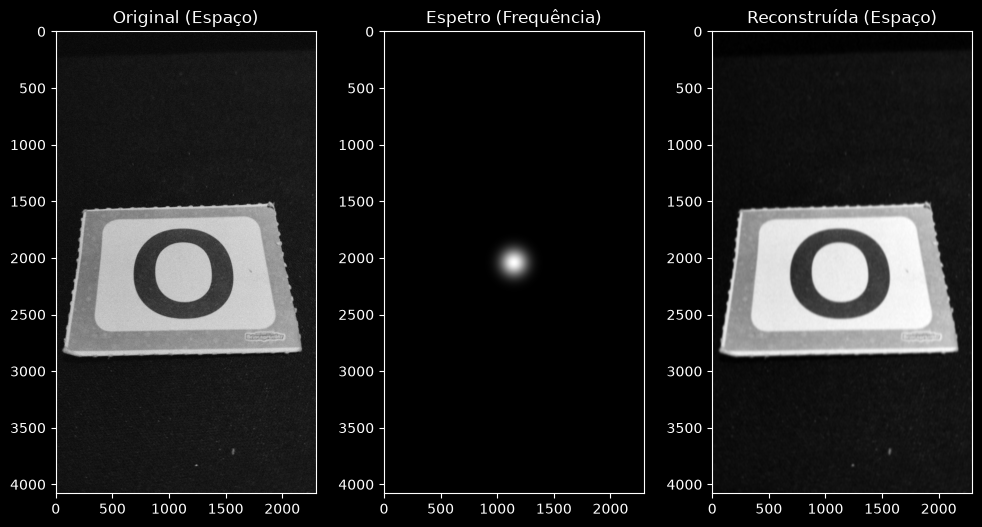

In [21]:
plotar(imagem_com_ruido_gaussiano, mascara_passa_baixa, imagem_limpa)

In [22]:
def criar_filtro_passa_alta_gaussiano(formato_imagem, raio_corte):
    mascara_baixa = criar_filtro_passa_baixa_gaussiano(formato_imagem, raio_corte)
    mascara_alta = 1 - mascara_baixa
    return mascara_alta

In [23]:
freq_bruta_orig = frequencia_bruta(img_o1)
freq_cent_orig = frequencia_centralizada(freq_bruta_orig)

In [24]:
mascara_passa_alta = criar_filtro_passa_alta_gaussiano(img_o1.shape, raio_corte=30)

In [25]:
freq_filtrada_alta = freq_cent_orig * mascara_passa_alta

freq_volta_alta = frequencia_deslocada_volta(freq_filtrada_alta)
img_reconstruida_alta = imagem_reconstruida(freq_volta_alta)
imagem_realcada = imagem_final_espaco(img_reconstruida_alta)

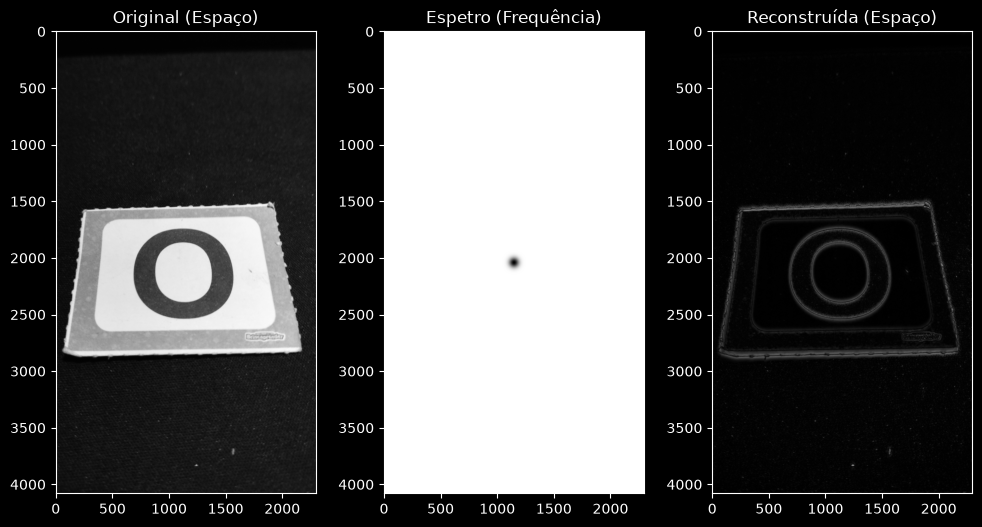

In [26]:
plotar(img_o1, mascara_passa_alta, imagem_realcada)

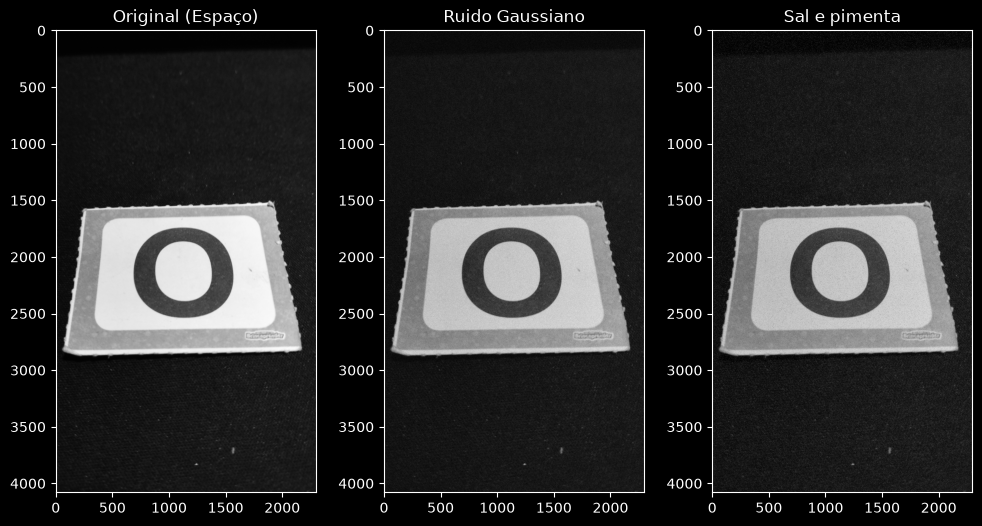

In [29]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1),
plt.imshow(img_o1, cmap="gray"),
plt.title("Original (Espaço)"),
plt.subplot(1, 3, 2),
plt.imshow(imagem_com_ruido_gaussiano, cmap="gray"),
plt.title("Ruido Gaussiano"),
plt.subplot(1, 3, 3),
plt.imshow(imagem_sal_pimenta, cmap="gray"),
plt.title("Sal e pimenta"),
plt.show()

### Parte 5 - Comparação Final

| Etapa | Resultado observado |
| :--- | :--- |
| **Imagem original** | A imagem base, nítida, sem ruídos e com iluminação padrão. |
| **Imagem com ruído gaussiano** | Apresenta um "chiado" distribuído por toda a imagem, degradando todos os pixéis de forma suave. |
| **Imagem com ruído sal e pimenta** | Apresenta pontos extremos brancos e pretos em 5% da imagem, mas preserva a nitidez nos pixéis não afetados. |
| **Imagem filtrada com gaussian** | O filtro passa-baixa eliminou o chiado do ruído, mas como efeito colateral, desfocou as bordas e os detalhes da imagem. |
| **Imagem com filtro passa-alta** | As texturas planas desapareceram (fundo escuro), realçando de forma isolada e brilhante apenas as bordas e os contornos da placa e da letra. |

• Qual ruído degradou mais a imagem?  
    O ruído gaussiano.  
• O filtro gaussiano conseguiu recuperar a qualidade visual?  
    Não totalmente, pois a imagem fica um pouco desfocada.  
• Em quais aplicações de visão computacional seria importante aplicar filtros antes do
processamento?  
    Imagens médicas.  